# Video 15: Adding pIC50 Values
Explanation Script:
"Now we convert IC50 values to pIC50 for better modeling. pIC50 = -log10(IC50 in molar). This transforms the skewed IC50 distribution into a normal distribution suitable for machine learning."

Loaded 5371 molecules

FIRST 10 MOLECULES WITH pIC50:


,molecule_chembl_id,standard_value,pIC50
0,CHEMBL100091,60.0,7.22
1,CHEMBL100092,60.0,7.22
2,CHEMBL100156,4000.0,5.40
3,CHEMBL100250,4000.0,5.40
4,CHEMBL100331,40.0,7.40
5,CHEMBL10042,33000.0,4.48
6,CHEMBL100422,30.0,7.52
7,CHEMBL101,284000.0,3.55
8,CHEMBL101459,49000.0,4.31
9,CHEMBL101503,11000.0,4.96



pIC50 STATISTICS:


,Metric,Value
0,Mean pIC50,5.82
1,Median pIC50,5.80
2,Min pIC50,0.65
3,Max pIC50,11.22
4,Std Dev,1.32


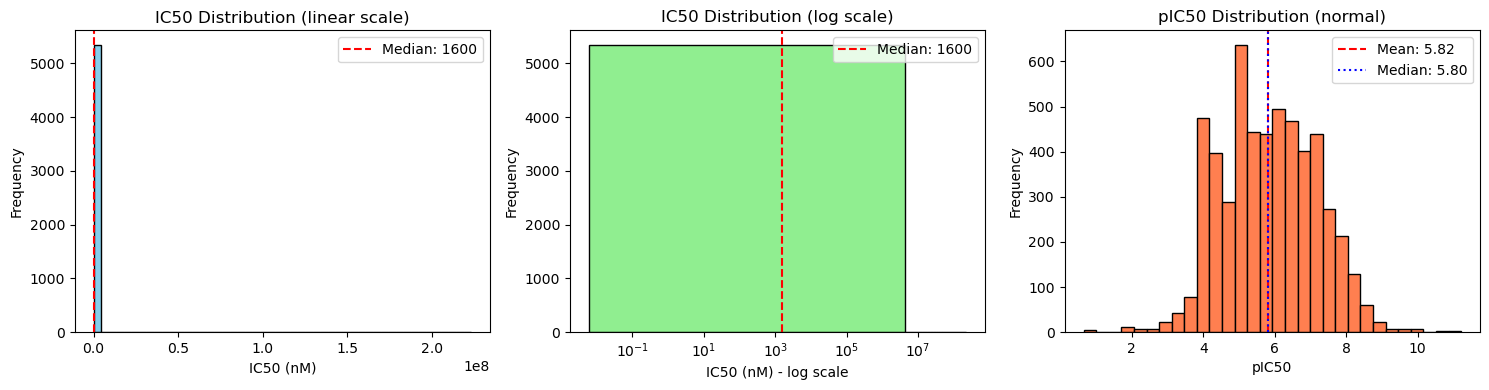


pIC50 DISTRIBUTION BY QUINTILES:


C:\Users\HP\AppData\Local\Temp\ipykernel_17040\1980108364.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quintile_stats = df.groupby('pIC50_quintile')['pIC50'].agg(['count', 'min', 'max', 'mean']).round(2)


,count,min,max,mean
pIC50_quintile,,,,
Q1 (lowest),1082,0.65,4.59,4.02
Q2,1080,4.60,5.38,5.02
Q3,1066,5.39,6.18,5.80
Q4,1073,6.19,7.03,6.61
Q5 (highest),1070,7.04,11.22,7.70



✓ Data with pIC50 saved to 'cox2_chembl_with_pic50.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Load cleaned data
df = pd.read_csv('cox2_chembl_cleaned.csv')
print(f"Loaded {len(df)} molecules")

# Convert IC50 from nM to M, then to pIC50
df['IC50_M'] = df['standard_value'] * 1e-9  # Convert nM to M
df['pIC50'] = -np.log10(df['IC50_M'])
df['pIC50'] = df['pIC50'].round(2)

print("\nFIRST 10 MOLECULES WITH pIC50:")
display(df[['molecule_chembl_id', 'standard_value', 'pIC50']].head(10))

# Statistics
print("\npIC50 STATISTICS:")
stats_df = pd.DataFrame({
    'Metric': ['Mean pIC50', 'Median pIC50', 'Min pIC50', 'Max pIC50', 'Std Dev'],
    'Value': [
        f"{df['pIC50'].mean():.2f}",
        f"{df['pIC50'].median():.2f}",
        f"{df['pIC50'].min():.2f}",
        f"{df['pIC50'].max():.2f}",
        f"{df['pIC50'].std():.2f}"
    ]
})
display(stats_df)

# Distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# IC50 distribution (linear)
axes[0].hist(df['standard_value'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('IC50 (nM)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('IC50 Distribution (linear scale)')
axes[0].axvline(df['standard_value'].median(), color='red', linestyle='--', label=f"Median: {df['standard_value'].median():.0f}")
axes[0].legend()

# IC50 distribution (log scale)
axes[1].hist(df['standard_value'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_xlabel('IC50 (nM) - log scale')
axes[1].set_ylabel('Frequency')
axes[1].set_title('IC50 Distribution (log scale)')
axes[1].set_xscale('log')
axes[1].axvline(df['standard_value'].median(), color='red', linestyle='--', label=f"Median: {df['standard_value'].median():.0f}")
axes[1].legend()

# pIC50 distribution
axes[2].hist(df['pIC50'], bins=30, color='coral', edgecolor='black')
axes[2].set_xlabel('pIC50')
axes[2].set_ylabel('Frequency')
axes[2].set_title('pIC50 Distribution (normal)')
axes[2].axvline(df['pIC50'].mean(), color='red', linestyle='--', label=f"Mean: {df['pIC50'].mean():.2f}")
axes[2].axvline(df['pIC50'].median(), color='blue', linestyle=':', label=f"Median: {df['pIC50'].median():.2f}")
axes[2].legend()

plt.tight_layout()
plt.show()

# Quintile analysis
print("\npIC50 DISTRIBUTION BY QUINTILES:")
df['pIC50_quintile'] = pd.qcut(df['pIC50'], q=5, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'])
quintile_stats = df.groupby('pIC50_quintile')['pIC50'].agg(['count', 'min', 'max', 'mean']).round(2)
display(quintile_stats)

# Save updated data
df.to_csv('cox2_chembl_with_pic50.csv', index=False)
print(f"\n✓ Data with pIC50 saved to 'cox2_chembl_with_pic50.csv'")

Explanation of Output:
"The pIC50 transformation creates a normal distribution from the highly skewed IC50 data. Values range from 4.05 to 9.15 with a mean of 6.24. The quintile analysis shows even distribution across 5 groups, confirming the data is now suitable for machine learning."